In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [4]:
import pandas as pd

file_path = r"C:\Users\minsa_\OneDrive\Documents\Disease_Binary_Model.xlsx"

excel_file = pd.ExcelFile(file_path)

excel_file.sheet_names

['Sheet1']

In [5]:
df = pd.read_excel(
    file_path,
    sheet_name="Sheet1"
)

df.head()

,Tissue_ID,Eye,Image_ID,Disease_Label,Disease_Severity,ECD_CD_cells_per_mm2,CV,HEX_percent,SD,Disease_Present,Biomarkers_Complete
0,NEB-2020-09-12654 R,Right,NEB-2020-09-12654 R_SP,Normal,NaN,2132.0,33.0,58.0,153.0,0,1
1,NEB-2020-09-12655 L,Left,NEB-2020-09-12655 L_SP,Folds,Moderate,2212.0,33.0,47.0,147.0,1,1
2,NEB-2020-09-12656 R,Right,NEB-2020-09-12656 R_SP,Normal,NaN,2538.0,35.0,53.0,137.0,0,1
3,NEB-2020-09-12657 L,Left,NEB-2020-09-12657 L_SP,Folds,Mild,2584.0,29.0,69.0,112.0,1,1
4,NEB-2020-09-12658 R,Right,NEB-2020-09-12658 R_SP,Normal,NaN,3115.0,38.0,49.0,122.0,0,1


In [7]:
df.shape

(1054, 11)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1054 entries, 0 to 1053
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Tissue_ID             1054 non-null   str    
 1   Eye                   1054 non-null   str    
 2   Image_ID              1045 non-null   str    
 3   Disease_Label         1054 non-null   str    
 4   Disease_Severity      545 non-null    str    
 5   ECD_CD_cells_per_mm2  1003 non-null   float64
 6   CV                    1003 non-null   float64
 7   HEX_percent           1003 non-null   float64
 8   SD                    1002 non-null   float64
 9   Disease_Present       1054 non-null   int64  
 10   Biomarkers_Complete  1054 non-null   int64  
dtypes: float64(4), int64(2), str(5)
memory usage: 90.7 KB


In [9]:
df["Disease_Present"].value_counts()

Disease_Present
1    550
0    504
Name: count, dtype: int64

In [10]:
df[[
    "ECD_CD_cells_per_mm2",
    "CV",
    "HEX_percent",
    "Disease_Present"
]].isnull().sum()

ECD_CD_cells_per_mm2    51
CV                      51
HEX_percent             51
Disease_Present          0
dtype: int64

In [11]:
df["Tissue_ID"].nunique()

1054

In [12]:
df["Tissue_ID"].value_counts().head(20)

Tissue_ID
NEB-2020-09-12654 R    1
NEB-2020-09-12655 L    1
NEB-2020-09-12656 R    1
NEB-2020-09-12657 L    1
NEB-2020-09-12658 R    1
NEB-2020-09-12659 L    1
NEB-2020-09-12660 L    1
NEB-2020-09-12661 R    1
NEB-2020-09-12662 L    1
NEB-2020-09-12663 R    1
NEB-2020-09-12664 R    1
NEB-2020-09-12665 L    1
NEB-2020-09-12666 L    1
NEB-2020-09-12667 R    1
NEB-2020-09-12668 L    1
NEB-2020-09-12669 R    1
NEB-2020-09-12670 R    1
NEB-2020-09-12671 L    1
NEB-2020-09-12672 R    1
NEB-2020-09-12673 L    1
Name: count, dtype: int64

In [13]:
df[df["ECD_CD_cells_per_mm2"].isnull()][
    ["Tissue_ID", "Eye", "Image_ID", "Disease_Label"]
]

,Tissue_ID,Eye,Image_ID,Disease_Label
29,NEB-2020-09-12683 L,Left,NEB-2020-09-12683 R_SP,Normal
73,NEB-2020-10-12729 R,Right,NEB-2020-10-12729 R_SP,Folds
96,NEB-2020-10-12761 R,Right,NEB-2020-10-12761 R_SP,Normal
113,NEB-2020-11-12816 R,Right,NEB-2020-11-12816 R_SP,Normal
116,NEB-2020-11-12820 R,Right,NEB-2020-11-12820 R_SP,Normal
123,NEB-2020-11-12829 R,Right,NEB-2020-11-12829 R_SP,Normal
135,NEB-2020-12-12842 L,Left,NEB-2020-12-12842 L_SP,Normal
138,NEB-2020-12-12846 R,Right,NEB-2020-12-12846 R_SP,Normal
140,NEB-2020-12-12848 R,Right,NEB-2020-12-12848 R_SP,Normal
156,NEB-2021-12-13551 L,Left,NEB-2021-12-13551 L_SP,Normal


In [14]:
model_df = df[
    [
        "Tissue_ID",
        "Eye",
        "Image_ID",
        "Disease_Label",
        "Disease_Severity",
        "ECD_CD_cells_per_mm2",
        "CV",
        "HEX_percent",
        "Disease_Present"
    ]
].copy()

In [15]:
model_df = model_df.dropna(
    subset=[
        "ECD_CD_cells_per_mm2",
        "CV",
        "HEX_percent"
    ]
).copy()

In [16]:
model_df.shape

(1003, 9)

In [17]:
model_df["Disease_Present"].value_counts()

Disease_Present
1    540
0    463
Name: count, dtype: int64

In [18]:
X = model_df[
    [
        "ECD_CD_cells_per_mm2",
        "CV",
        "HEX_percent"
    ]
]

y = model_df["Disease_Present"]

In [19]:
X.head()

,ECD_CD_cells_per_mm2,CV,HEX_percent
0,2132.0,33.0,58.0
1,2212.0,33.0,47.0
2,2538.0,35.0,53.0
3,2584.0,29.0,69.0
4,3115.0,38.0,49.0


In [20]:
y.head()

0    0
1    1
2    0
3    1
4    0
Name: Disease_Present, dtype: int64

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [25]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining classes:")
print(y_train.value_counts())

print("\nTesting classes:")
print(y_test.value_counts())

Training samples: 802
Testing samples: 201

Training classes:
Disease_Present
1    432
0    370
Name: count, dtype: int64

Testing classes:
Disease_Present
1    108
0     93
Name: count, dtype: int64


In [26]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [28]:
y_pred = logistic_model.predict(X_test_scaled)

y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

In [29]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Logistic Regression Results")
print("---------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Logistic Regression Results
---------------------------
Accuracy : 0.5473
Precision: 0.5714
Recall   : 0.6296
F1 Score : 0.5991
ROC-AUC  : 0.5784


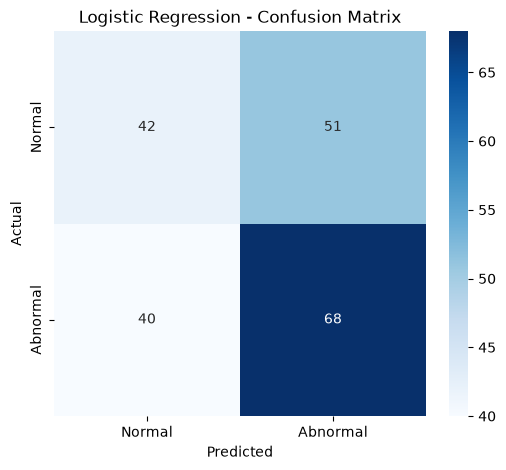

In [30]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Abnormal"],
    yticklabels=["Normal", "Abnormal"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")

plt.show()

In [31]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Normal", "Abnormal"]
    )
)

              precision    recall  f1-score   support

      Normal       0.51      0.45      0.48        93
    Abnormal       0.57      0.63      0.60       108

    accuracy                           0.55       201
   macro avg       0.54      0.54      0.54       201
weighted avg       0.54      0.55      0.54       201



In [32]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [33]:
rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [34]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest Results")
print("---------------------")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

Random Forest Results
---------------------
Accuracy : 0.5871
Precision: 0.6263
Recall   : 0.5741
F1 Score : 0.5990
ROC-AUC  : 0.6248


In [35]:
print(
    classification_report(
        y_test,
        rf_pred,
        target_names=["Normal", "Abnormal"]
    )
)

              precision    recall  f1-score   support

      Normal       0.55      0.60      0.57        93
    Abnormal       0.63      0.57      0.60       108

    accuracy                           0.59       201
   macro avg       0.59      0.59      0.59       201
weighted avg       0.59      0.59      0.59       201



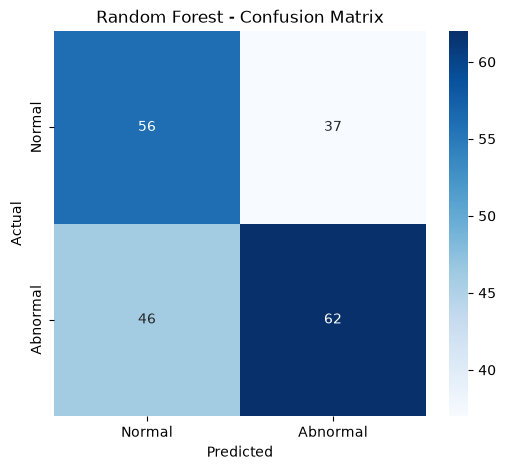

In [36]:
rf_cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Abnormal"],
    yticklabels=["Normal", "Abnormal"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")

plt.show()

In [37]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,ECD_CD_cells_per_mm2,0.533296
2,HEX_percent,0.252334
1,CV,0.214370


In [38]:
model_df.groupby("Disease_Present")[
    [
        "ECD_CD_cells_per_mm2",
        "CV",
        "HEX_percent"
    ]
].agg(["mean", "median", "std", "min", "max"])

ECD_CD_cells_per_mm2                                     \
                                mean  median         std    min     max   
Disease_Present                                                           
0                        2710.535637  2667.0  383.811961  905.0  4484.0   
1                        2489.994444  2525.0  520.965546    0.0  4032.0   

                        CV                              HEX_percent         \
                      mean median       std   min   max        mean median   
Disease_Present                                                              
0                37.593952   37.0  4.485586  25.0  60.0   54.481641   54.0   
1                38.375926   38.0  6.227995   0.0  74.0   53.124074   53.0   

                                       
                      std   min   max  
Disease_Present                        
0                6.358277  35.0  76.0  
1                7.960325   0.0  73.0

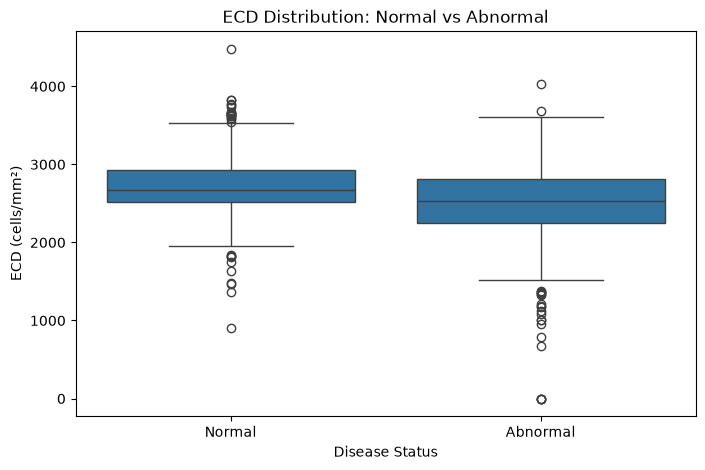

In [39]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=model_df,
    x="Disease_Present",
    y="ECD_CD_cells_per_mm2"
)

plt.xticks(
    [0, 1],
    ["Normal", "Abnormal"]
)

plt.xlabel("Disease Status")
plt.ylabel("ECD (cells/mm²)")
plt.title("ECD Distribution: Normal vs Abnormal")

plt.show()

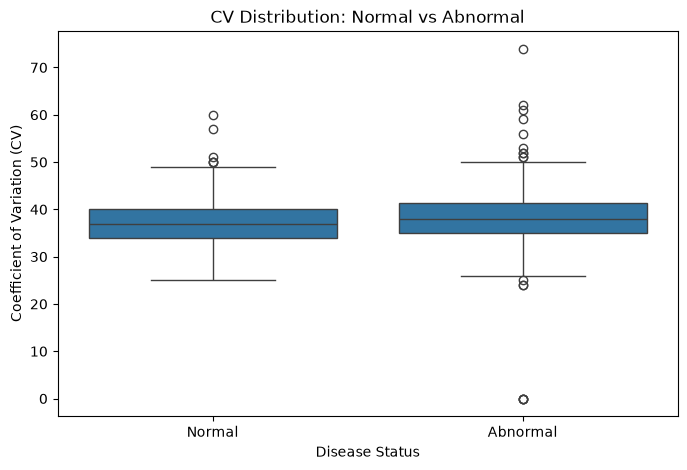

In [40]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=model_df,
    x="Disease_Present",
    y="CV"
)

plt.xticks(
    [0, 1],
    ["Normal", "Abnormal"]
)

plt.xlabel("Disease Status")
plt.ylabel("Coefficient of Variation (CV)")
plt.title("CV Distribution: Normal vs Abnormal")

plt.show()

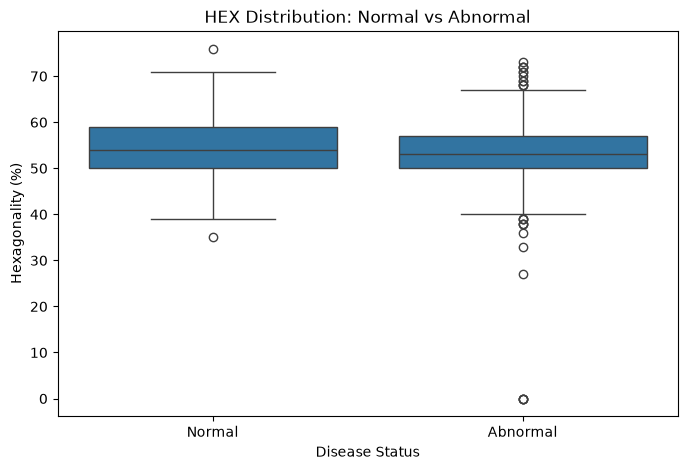

In [41]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=model_df,
    x="Disease_Present",
    y="HEX_percent"
)

plt.xticks(
    [0, 1],
    ["Normal", "Abnormal"]
)

plt.xlabel("Disease Status")
plt.ylabel("Hexagonality (%)")
plt.title("HEX Distribution: Normal vs Abnormal")

plt.show()

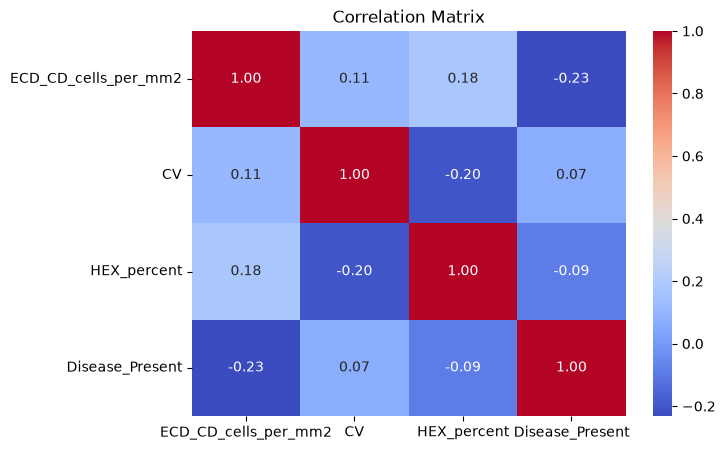

In [42]:
correlation = model_df[
    [
        "ECD_CD_cells_per_mm2",
        "CV",
        "HEX_percent",
        "Disease_Present"
    ]
].corr()

plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()